In [5]:
# -*- coding: utf-8 -*-
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.linalg as la
from pathlib import Path
from multiprocessing import Pool, cpu_count


# =============================
# System (Majorana/BdG) + MF machinery
# =============================

class System:
    def __init__(self, T, L, t, mu, W, delta, U, V,
                 disorder, disorder1, disorder_gamma, disorder_eta,
                 npf, pbc, trs, tr_inv):
        """
        T: temperature (unused here; 0-T projector used)
        trs: scaling for TRS-conserving off-diagonal (gamma/eta) terms (0 or 1)
        tr_inv: enforce translational invariance of mean-field channels per channel (uniform over space)
        NOTE: uses global W_ratio (TRS-breaking disorder amplitude ratio).
        """
        npf = np.asarray(npf, dtype=float).copy()
        if npf.size != 6 * L:
            raise ValueError(f"npf must have length 6*L; got {npf.size} for L={L}")

        # Enforce translation-invariant mean-field if requested (uniform per channel)
        if tr_inv:
            #for k in range(6):
            #    s, e = k * L, (k + 1) * L
            #    val = float(npf[s])     # or np.mean(npf[s:e])
            #    npf[s:e] = val
            npf[0:2*L]=npf[0]*np.ones(2*L)
            npf[2*L:4*L]=npf[2*L]*np.ones(2*L)
            npf[4*L:6*L]=npf[4*L]*np.ones(2*L)

        # Convenience array for boundary condition
        arr = np.ones(L, dtype=float)
        arr[0] = arr[-1] = pbc

        # Build MF channels (purely imaginary by construction)
        a1 = 1j * np.block([npf[L-1] * pbc, npf[0:L-1]])
        a2 = 1j * np.block([npf[1:L], npf[0] * pbc])
        d  = 1j * npf[3*L:4*L] * arr
        b  = 1j * npf[1*L:2*L]
        b1 = 1j * np.block([npf[2*L-1] * pbc, npf[1*L:2*L-1]])
        b2 = 1j * np.block([npf[1*L+1:2*L], npf[1*L] * pbc])
        c  = 1j * npf[2*L:3*L]

        i_gamma_j_gamma_jplus1 = 1j * npf[4*L:5*L]
        i_eta_j_eta_jplus1     = 1j * npf[5*L:6*L]

        e1 = np.block([i_eta_j_eta_jplus1[-1], i_eta_j_eta_jplus1[0:L-1]])
        e2 = np.block([i_eta_j_eta_jplus1[-2], i_eta_j_eta_jplus1[-1], i_eta_j_eta_jplus1[0:L-2]])
        f1 = np.block([i_gamma_j_gamma_jplus1[-1], i_gamma_j_gamma_jplus1[0:L-1]])
        f2 = i_gamma_j_gamma_jplus1

        # Majorana MF block
        H_mu = -1j * (-W * disorder + mu) * np.eye(L, k=0) - U * (a1 + a2) * np.eye(L, k=0) - V * d * np.eye(L, k=0)
        H_t  =  1j * (-t + delta) * np.eye(L, k=1) - U * b * np.eye(L, k=1)
        H_t[L-1, 0] = (1j * (-t + delta) - U * b[0]) * pbc
        H_t1 =  1j * (-t - delta - W * disorder1) * np.eye(L, k=-1) + U * c * np.eye(L, k=-1) + V * (b1 + b2) * np.eye(L, k=-1)
        H_t1[0, L-1] = (1j * (-t - delta - W * disorder1[0]) + U * c[L-1] + V * (b1[L-1] + b2[L-1])) * pbc
        H_t2 = V * a2 * np.eye(L, k=-2)
        H_t2[0, L-2] = V * a2[L-2] * pbc
        H_t2[1, L-1] = V * a2[L-1] * pbc
        H_maj_mf = H_mu + H_t + H_t1 + H_t2

        # TRS-conserving vs TRS-breaking (gamma/eta) blocks
        # trs multiplies the TRS-conserving MF couplings; W_ratio scales the TRS-breaking disorder pieces.
        H_gamma0 = trs * np.eye(L, k=1) * (-U * e1 - V * e2) + 1j * np.eye(L, k=1) * W * W_ratio * disorder_gamma
        H_eta0   = trs * np.eye(L, k=1) * (-U * f1 - V * f2) + 1j * np.eye(L, k=1) * W * W_ratio * disorder_eta
        H_gamma0[L-1, 0] = (trs * (-U * e1[0] - V * e2[0]) + 1j * W * W_ratio * disorder_gamma[0]) * pbc
        H_eta0[L-1, 0]   = (trs * (-U * f1[0] - V * f2[0]) + 1j * W * W_ratio * disorder_eta[0]) * pbc

        H_gamma = H_gamma0 - H_gamma0.T
        H_eta   = H_eta0 - H_eta0.T

        # Assemble Majorana Hamiltonian (Hermitian)
        H = np.block([[            H_gamma,         H_maj_mf],
                      [H_maj_mf.conj().T,              H_eta]])
        self.H = H

        # Ground-state projector (T=0)
        eigvalsU, eigvecsU = np.linalg.eigh(self.H)
        self.gamma_eta = (eigvecsU.conj()) @ np.diag(np.heaviside(-eigvalsU, 0.5)) @ (eigvecsU.T)
        self.gamma_eta = (eigvecsU.conj()) @ np.diag(1/(1+np.exp(eigvalsU/T))) @ (eigvecsU.T)

        # Rotate to complex-fermion basis
        majorana_to_c = np.sqrt(0.5) * np.block([[np.eye(L),  np.eye(L)],
                                                 [1j*np.eye(L), -1j*np.eye(L)]])
        self.nij = (majorana_to_c.conj().T) @ self.gamma_eta @ majorana_to_c

        self.L = L
        self.E = float(np.sum(eigvalsU * np.heaviside(-eigvalsU, 0.5)))

    def calculation_npf(self):
        """Build 6L mean-field channels (ai,bi,ci,di,xi,yi) from gamma-eta correlators."""
        L = self.L
        gamma_eta = (self.gamma_eta)[0:L, L:2*L]
        ai = np.zeros(L); bi = np.zeros(L); ci = np.zeros(L); di = np.zeros(L)
        for i in range(L):
            ai[i] = np.real((-1j) * gamma_eta[i, i])
            bi[i] = np.real(( 1j) * gamma_eta[(i+1) % L, i])
            ci[i] = np.real((-1j) * gamma_eta[i, (i+1) % L])
            di[i] = np.real(( 1j) * gamma_eta[(i+1) % L, (i-1) % L])

        gamma_gamma = (self.gamma_eta)[0:L, 0:L]
        eta_eta     = (self.gamma_eta)[L:2*L, L:2*L]
        xi = np.zeros(L); yi = np.zeros(L)
        for i in range(L):
            xi[i] = np.real((-1j) * gamma_gamma[i, (i+1) % L])
            yi[i] = np.real((-1j) * eta_eta[i, (i+1) % L])

        return np.block([ai, bi, ci, di, xi, yi])

    def ground_state_energy(self):
        return self.E

    def index_npf(self):
        """Return a bundle incl. eigenpairs and nij (for entanglement)."""
        w, v = np.linalg.eigh(self.H)
        return (0.0, None, (w, v), 0.0, 0.0, 0.0, 0.0, 0.0, self.nij, self.E)


# =============================
# Helpers
# =============================

def make_sinLx(L, lx_grid):
    """CFT x-variable for S(ℓ) fits (constant shifts go into s0)."""
    return np.array([ (1.0/3.0) * np.log( 2*(2*L)/np.pi * np.sin(np.pi*(2*lx)/(2*L)) )
                      for lx in lx_grid ], dtype=float)
    
def make_Lx(L, lx_grid):
    """CFT x-variable for S(ℓ) fits (constant shifts go into s0)."""
    return np.array([ 2*lx for lx in lx_grid ], dtype=float)


# =============================
# Globals plumbed into workers
# =============================

def setup_globals(WX_, g_, trs_, W_ratio_, tr_inv_,
                  dis_pool_, dis_pool1_, dis_pool2_, dis_pool3_,
                  *,  # keyword-only after this
                  L, t0, delta0, int_stagg, T, pbc,
                  VY_to_UY_ratio, mu0,
                  delta_mf, fric, jj_iter, mf_precision,
                  lx_set, Rq):
    """Make everything visible to worker processes without pickling closures."""
    global WX, g, trs, W_ratio, tr_inv
    global dis_pool, dis_pool1, dis_pool2, dis_pool3
    global GL_L, GL_t0, GL_delta0, GL_int_stagg, GL_T, GL_pbc
    global GL_Vratio, GL_mu0, GL_delta_mf, GL_fric, GL_jj_iter, GL_mf_prec
    global GL_lx_set, GL_Rq

    WX, g, trs, W_ratio, tr_inv = WX_, g_, trs_, W_ratio_, tr_inv_
    dis_pool, dis_pool1, dis_pool2, dis_pool3 = dis_pool_, dis_pool1_, dis_pool2_, dis_pool3_

    GL_L, GL_t0, GL_delta0, GL_int_stagg, GL_T, GL_pbc = L, t0, delta0, int_stagg, T, pbc
    GL_Vratio, GL_mu0 = VY_to_UY_ratio, mu0
    GL_delta_mf, GL_fric, GL_jj_iter, GL_mf_prec = delta_mf, fric, jj_iter, mf_precision
    GL_lx_set, GL_Rq = np.array(lx_set, int), int(Rq)


# =============================
# Worker: one disorder realization → S_ent(lx) array
# =============================

def entropy_data(i_dis: int):
    """Compute S_ent(lx) for a single disorder realization index i_dis."""
    v = i_dis  # row in pools: (dis_number, L)

    UY = 2.0 * g
    VY = GL_Vratio * UY

    # initial MF vector (6L channels)
    npf2 = GL_delta_mf * np.random.uniform(low=-1.0, high=1.0, size=6 * GL_L)

    # optional bootstrap pass to get a better starting point
    sys0 = System(T=GL_T, L=GL_L, t=GL_t0, mu=GL_mu0, W=WX, delta=GL_delta0,
                  U=0.0, V=0.0,
                  disorder=dis_pool[v, :],
                  disorder1=dis_pool1[v, :],
                  disorder_gamma=dis_pool2[v, :],
                  disorder_eta=dis_pool3[v, :],
                  npf=npf2, pbc=GL_pbc, trs=trs, tr_inv=tr_inv)
    npf2 = sys0.calculation_npf()

    # MF iterations (damped fixed-point)
    jj = 0
    npf2y = npf2
    while jj < GL_jj_iter:
        #npf2x = npf2y
        sys = System(T=GL_T, L=GL_L, t=GL_t0, mu=GL_mu0, W=WX, delta=GL_delta0,
                     U=UY, V=VY,
                     disorder=dis_pool[v, :],
                     disorder1=dis_pool1[v, :],
                     disorder_gamma=dis_pool2[v, :],
                     disorder_eta=dis_pool3[v, :],
                     npf=npf2, pbc=GL_pbc, trs=trs, tr_inv=tr_inv)
        npf2y = sys.calculation_npf()
        eps = float(np.max(np.abs(npf2 - npf2y)))
        if eps < GL_mf_prec:
            break
        npf2 = (1.0 - GL_fric) * npf2y + GL_fric * npf2
        jj += 1

    # Final system for observables
    sys = System(T=GL_T, L=GL_L, t=GL_t0, mu=GL_mu0, W=WX, delta=GL_delta0,
                 U=UY, V=VY,
                 disorder=dis_pool[v, :],
                 disorder1=dis_pool1[v, :],
                 disorder_gamma=dis_pool2[v, :],
                 disorder_eta=dis_pool3[v, :],
                 npf=npf2, pbc=GL_pbc, trs=trs, tr_inv=tr_inv)
    RESULTS = sys.index_npf()
    nij = RESULTS[8]

    # S_ent(l) averaged over all windows at each l
    out = []
    for lx in GL_lx_set:
        q = 0
        S_ent = 0.0
        while q <= (GL_L - lx):
            qx = GL_Rq * q
            if qx > GL_L - lx - 1:
                break
            Cij = np.block([
                [nij[qx:qx+lx, qx:qx+lx],           nij[qx:qx+lx, qx+GL_L:qx+GL_L+lx]],
                [nij[qx+GL_L:qx+GL_L+lx, qx:qx+lx], nij[qx+GL_L:qx+GL_L+lx, qx+GL_L:qx+GL_L+lx]]
            ])
            Lambda, _ = la.eig(Cij)
            mask = (np.abs(Lambda) > 0) & (np.abs(Lambda) < 1)
            if np.any(mask):
                S_ent = (q * S_ent - np.sum(Lambda[mask] * np.log(Lambda[mask]))) / (q + 1)
            q += 1
        out.append(np.real(S_ent))

    return np.asarray(out, float)


# =============================
# Runner for one set (W, g, trs, W_ratio, tr_inv)
# =============================

def run_one_set(name,
                # --- GLOBALS shared across sets ---
                L=200, t0=0.5, delta0=0.5, int_stagg=1,
                T=1.0, pbc=1, VY_to_UY_ratio=1.0,
                delta_mf=1e-3, fric=0.5, jj_iter=100, mf_precision=1e-9,
                lx0=20, lx1=70, lx2=100, dlx=5, Rq=1, rng_seed=12345,
                out_dir="entropy_extrapolation",
                # --- SET-SPECIFIC (this is what varies across sets) ---
                W=0.5, g=0.2, trs=1, W_ratio=1.0, tr_inv=False, dis_number=1):

    mu0 = -int_stagg * (t0 + delta0)

    # grids (depend on L)
    lx_set = np.arange(lx0, lx2 + dlx, dlx, dtype=int)
    lx_set_extrapol = np.arange(lx0, lx1 + dlx, dlx, dtype=int)
    sinLx = make_sinLx(L, lx_set)
    #sinLx = make_Lx(L, lx_set)
    sinLx_extrapol = make_sinLx(L, lx_set_extrapol)

    # disorder pools for this set (dis_number × L)
    rs = np.random.RandomState(rng_seed)
    dis_pool_  = rs.uniform(-1.0, 1.0, size=(dis_number, L))
    dis_pool1_ = rs.uniform(-1.0, 1.0, size=(dis_number, L))
    dis_pool2_ = rs.uniform(-1.0, 1.0, size=(dis_number, L))
    dis_pool3_ = rs.uniform(-1.0, 1.0, size=(dis_number, L))

    # stash globals for workers
    setup_globals(W, g, trs, W_ratio, tr_inv,
                  dis_pool_, dis_pool1_, dis_pool2_, dis_pool3_,
                  L=L, t0=t0, delta0=delta0, int_stagg=int_stagg, T=T, pbc=pbc,
                  VY_to_UY_ratio=VY_to_UY_ratio, mu0=mu0,
                  delta_mf=delta_mf, fric=fric, jj_iter=jj_iter, mf_precision=mf_precision,
                  lx_set=lx_set, Rq=Rq)

    # parallel over disorder
    with Pool(processes=min(cpu_count(), dis_number)) as pool:
        X_list = pool.map(entropy_data, list(range(dis_number)))

    X_D = np.vstack(X_list)                 # (dis_number, len(sinLx))
    S_ent_DATA = np.mean(X_D, axis=0)       # (len(sinLx),)

    # persist
    out_path = Path(out_dir); out_path.mkdir(parents=True, exist_ok=True)
    np.save(out_path / f"X_D__{name}.npy", X_D)
    np.save(out_path / f"S_ent_DATA__{name}.npy", S_ent_DATA)
    np.save(out_path / f"sinLx__{name}.npy", sinLx)
    np.save(out_path / f"sinLx_extrapol__{name}.npy", sinLx_extrapol)

    print(f"[{name}] X_D shape {X_D.shape} | S_ent_DATA shape {S_ent_DATA.shape}")
    return X_D, S_ent_DATA, sinLx, sinLx_extrapol


# =============================
# Main: define four sets & run
# =============================

if __name__ == "__main__":
    # --- globals shared across sets ---
    base = dict(
        L=200, t0=0.5, delta0=0.5, int_stagg=1,
        T=0.0, pbc=1, VY_to_UY_ratio=1.0,
        delta_mf=1e-3, fric=0.5, jj_iter=100, mf_precision=1e-9,
        lx0=2, lx1=50, lx2=100, dlx=5, Rq=1,
        out_dir="entropy_extrapolation"
    )

    # --- four parameter sets: (W, g, trs, W_ratio, tr_inv) ---
    param_sets = [
        dict(name="clean_noninteracting", W=0.0, g=0.0, trs=0, W_ratio=0.0, tr_inv=False, rng_seed=101, dis_number=1),
        dict(name="clean_floating_phase", W=0.0, g=0.4, trs=0, W_ratio=0.0, tr_inv=True, rng_seed=102, dis_number=1),
        dict(name="IRFP_BDI", W=0.90, g=0.0, trs=0, W_ratio=0.0, tr_inv=False,  rng_seed=103, dis_number=20),
        #dict(name="localization_BDI", W=0.4, g=0.3, trs=0, W_ratio=0.0, tr_inv=False,  rng_seed=104, dis_number=20),
    ]

    results = []
    for ps in param_sets:
        cfg = {**base, **ps}
        results.append(run_one_set(**cfg))

    # Optional: unpack
    X_D_list        = [r[0] for r in results]  # 4 items, each (dis_number, |sinLx|)
    S_ent_DATA_list = [r[1] for r in results]  # 4 items, each (|sinLx|)
    print("Done.")


[clean_noninteracting] X_D shape (1, 21) | S_ent_DATA shape (21,)
[clean_floating_phase] X_D shape (1, 21) | S_ent_DATA shape (21,)
[IRFP_BDI] X_D shape (20, 21) | S_ent_DATA shape (21,)
Done.


Text(0, 0.5, '$S(\\ell)$')

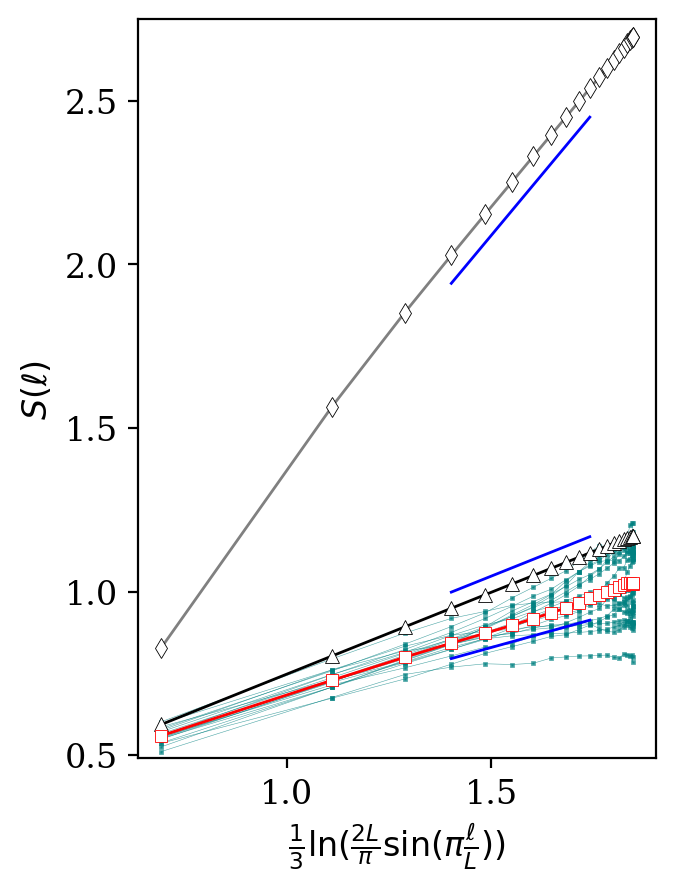

In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pylab as plt
from scipy.optimize import curve_fit
import multiprocessing
import sympy as sp
from sympy import symbols, Eq, solve, nsolve
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
import pickle
from pathlib import Path
from multiprocessing import Pool
import scipy.linalg as la
import warnings
warnings.filterwarnings("ignore")

rng = np.random.default_rng()

cpu_number=multiprocessing.cpu_count()

from scipy.optimize  import minimize
from scipy.optimize  import optimize
from scipy.optimize  import NonlinearConstraint

import mpmath
from mpmath import *
import scipy

import numpy as np
from scipy.linalg import expm, sinm, cosm

from scipy.optimize  import minimize
from scipy.optimize  import optimize
from scipy.optimize  import NonlinearConstraint
from matplotlib.ticker import MaxNLocator

import math
from scipy import special
from scipy.integrate import quad
from sympy import *
import math
from scipy import special
from scipy.integrate import quad

import pandas as pd
import scipy.special as sc

from scipy.linalg import sqrtm
pltp.rc('text', usetex=False)
pltp.rc('font', family='serif', size=12)

plt.rcParams["figure.dpi"] = 200
fig, ax = plt.subplots()
ax.set_aspect(0.8)
# -------------------------
# load data saved by the four-set runner
# -------------------------
out_dir = Path("entropy_extrapolation")

def load_set(name):
    sinLx  = np.load(out_dir / f"sinLx__{name}.npy")
    sinLx2 = np.load(out_dir / f"sinLx_extrapol__{name}.npy")
    X_D    = np.load(out_dir / f"X_D__{name}.npy")              # (dis_number, |sinLx|)
    Smean  = np.load(out_dir / f"S_ent_DATA__{name}.npy")       # (|sinLx|,)
    return sinLx, sinLx2, X_D, Smean

# Map saved sets to the template variables
# set_A ~ BDI-like (trs=0, W_ratio=0)
# set_B ~ D-like (trs=1, W_ratio>0)
# set_C/D ~ tr_inv variants (used for "clean_tr_inv" curves in the template)
sinLx_A, sinLx_2_A, X_A, S_A = load_set("clean_noninteracting")
sinLx_B, sinLx_2_B, X_B, S_B = load_set("clean_floating_phase")
sinLx_C, sinLx_2_C, X_C, S_C = load_set("IRFP_BDI")
sinLx_D, sinLx_2_D, X_Dset, S_Dset = load_set("localization_BDI")

# sanity: use the first set’s axes (assuming same L / grid)
sinLx   = sinLx_A
sinLx_2 = sinLx_2_A

for j in range(len(X_C)):
    x = sinLx
    y = X_Dset[j]
    #ax.plot(
    #    x, y,
    #    's-', linewidth=0.2, ms=0.5, alpha=1,
    #    color="green"  # or: color=cmap(element / max(1, dis_number-1))
    #)
    
for j in range(len(X_C)):
    x = sinLx
    y = X_C[j]
    ax.plot(
        x, y,
        's-', linewidth=0.2,   ms=0.7,
        color="teal", alpha=0.7 # or: color=cmap(element / max(1, dis_number-1))
    )

plt.plot(sinLx, S_A, '^-', color='black', linewidth=1,  mfc='white', 
         mec='black',        # edge color
         mew=0.3,  ms=5, alpha= 1)

plt.plot(sinLx, S_B, 'd-', color='grey', linewidth=1,  mfc='white', 
         mec='black',        # edge color
         mew=0.3,  ms=5, alpha= 1)

plt.plot(sinLx, S_C, 's-', color='red', linewidth=1, mfc='white', 
         mec='red',        # edge color
         mew=0.3,  ms=4, alpha= 1)

#plt.plot(sinLx, S_Dset, 's-', color='blue', linewidth=1,  ms=3, alpha= 1)

ax.plot(sinLx_2[3:], (0.5)*np.asarray(sinLx_2[3:] - sinLx_2[0]) + S_A[0] + 0.05, color='blue', linewidth=1)
ax.plot(sinLx_2[3:], (0.5*np.log(2))*np.asarray(sinLx_2[3:] - sinLx_2[0]) + S_C[0] - 0.01, color='blue', linewidth=1)
ax.plot(sinLx_2[3:], (1.5)*np.asarray(sinLx_2[3:] - sinLx_2[0]) + S_B[0]+0.05, color='blue', linewidth=1)
ax.set_ylim(0.49,2.75)
plt.xlabel(r'$\frac{1}{3}\ln(\frac{2L}{\pi} \sin(\pi \frac{\ell}{L}))$', fontsize=12)
plt.ylabel(r'$S(\ell)$', fontsize=12)
#ax.set_xlim(0.5,2)
#ax.plot(sinLx_2, (0.0)*np.asarray(sinLx_2 - sinLx_2[0]) + S_Dset[3] + 0.07, color='blue', linewidth=1)